### **Notebook 02 – Exploratory analysis and plots for Velo/Fuss + MeteoSwiss**

In this notebook we perform the following exploratory analysis on the prepared `merged_dataset.csv`:

- Visualize weekly totals of Velo/Fuss counts over the year.
- Inspect relationships between daily counts and key weather variables using scatter plots.
- Study aggregated patterns by temperature, precipitation, weekday and weekend.
- Quantify linear relationships via a Pearson correlation matrix.

The input is the merged daily-level dataset created in notebook `01_build_merged_dataset.ipynb`.

#### **Imports and configuration**

We import the required libraries for analysis and plotting, configure a consistent seaborn style, and define the relative path to the merged dataset. 

Using a relative path keeps the notebook reproducible as long as the repository structure is preserved.

In [1]:
# ---------------- Imports and Configuration ----------------
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------- Paths ----------------
DATA_DIR = Path("data")
MERGED_CSV = DATA_DIR / "merged_dataset.csv"

print("Current working directory :", Path(".").resolve())
print("Merged dataset path       :", MERGED_CSV)

# Sanity check: merged dataset must exist (produced by notebook 01)
assert MERGED_CSV.exists(), f"File not found: {MERGED_CSV}"

# Load merged daily dataset
merged_df = pd.read_csv(MERGED_CSV, parse_dates=["date"])
print("\nMerged dataset (head):")
display(merged_df.head(3))

# Years present in the dataset (useful for plots that loop over years)
YEARS = sorted(merged_df["date"].dt.year.unique())
print("\nYears present in merged dataset:", *YEARS)

# Keep only sites with full daily coverage (stable panel) for aggregated analysis
expected_days = merged_df["date"].nunique()

stable_sites = (
    merged_df.groupby("SiteCode")["date"].nunique()
    .eq(expected_days)
)
stable_sites = stable_sites[stable_sites].index

df_stable = merged_df[merged_df["SiteCode"].isin(stable_sites)].copy()

excluded_sites = sorted(set(merged_df["SiteCode"].unique()) - set(stable_sites))

print("\nDays in dataset:", expected_days)
print("SiteCodes (all):", merged_df["SiteCode"].nunique())
print("SiteCodes (stable):", df_stable["SiteCode"].nunique())
print("Excluded (partial coverage):", excluded_sites)

Current working directory : C:\FHNW\Robot_Challenge_zumi\DAW_daily_temperatur_and_pedestrians
Merged dataset path       : data\merged_dataset.csv

Merged dataset (head):


,SiteCode,SiteName,date,daily_total,temp_mean_C,precip_mm,wind_mean_ms,weekday,is_weekend
0,350,350 Dreirosenbrücke,2024-01-01,1825,6.3000,1.7,2.820833,Monday,False
1,350,350 Dreirosenbrücke,2024-01-02,2166,8.6625,8.4,5.141667,Tuesday,False
2,350,350 Dreirosenbrücke,2024-01-03,3379,11.2375,3.9,6.758333,Wednesday,False



Years present in merged dataset: 2024

Days in dataset: 366
SiteCodes (all): 40
SiteCodes (stable): 37
Excluded (partial coverage): [np.int64(813), np.int64(911), np.int64(920)]


#### **Weekly totals – Time series overview**

In this section we visualize **weekly total Velo/Fuss counts** aggregated across all sites.  

This provides:
- A compact time-series view over the full year.
- A sanity check for calendar coverage (no obvious missing weeks).
- A first impression of seasonal patterns in the overall mobility volume.



Generating weekly bar charts...


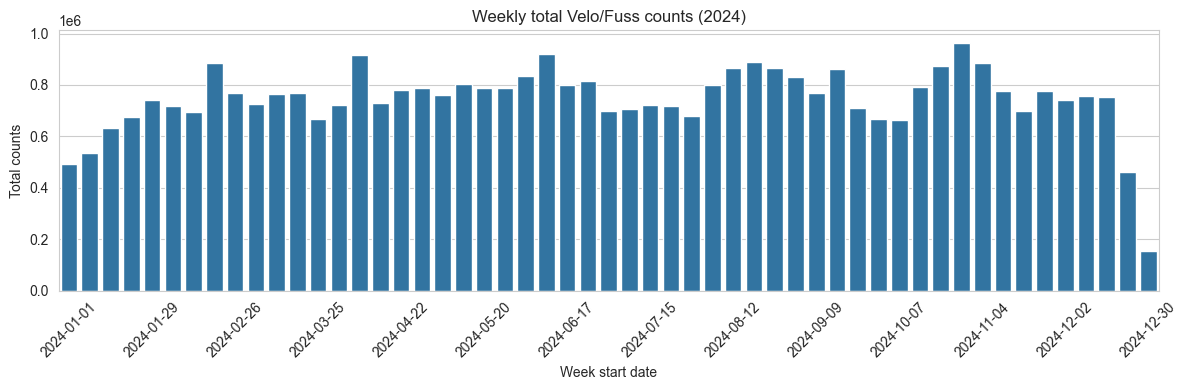

In [2]:
# ---------------- Weekly totals bar plots ----------------
def plot_weekly_bar(merged_df, years):
    """Weekly total counts across all sites."""
    print("\nGenerating weekly bar charts...")
    for year in years:
        df_year = merged_df[merged_df["date"].dt.year == year]
        weekly = (
            df_year.groupby(df_year["date"].dt.to_period("W"))["daily_total"]
            .sum()
            .reset_index()
        )
        weekly["week_start"] = weekly["date"].dt.start_time
        tick_idx = np.arange(0, len(weekly), 4)

        plt.figure(figsize=(12, 4))
        sns.barplot(data=weekly, x="week_start", y="daily_total")
        plt.title(f"Weekly total Velo/Fuss counts ({year})")
        plt.xlabel("Week start date")
        plt.ylabel("Total counts")
        plt.xticks(
            tick_idx,
            weekly["week_start"].dt.strftime("%Y-%m-%d").iloc[tick_idx],
            rotation=45,
        )
        plt.tight_layout()
        plt.show()


# Run weekly totals overview
plot_weekly_bar(df_stable, YEARS)

#### **Interpretation – Weekly totals**

There are significant temporal trends, amount of traffic seems to vary by seasons. The low correlation to the weather data implies that this is indeed correlated with time and not weather.

</br>

</br>


#### **Daily counts vs weather – Scatter plots with linear trend**

Next, we inspect the relationship between daily Velo/Fuss counts and the main weather variables:

- Daily mean temperature [°C]: `temp_mean_C`
- Daily precipitation [mm]: `precip_mm`
- Daily mean wind speed [m/s]: `wind_mean_ms`

For each feature we create a scatter plot with a ***linear trend line***.  
This helps us to see whether there is any visible monotonic relationship (even if weak) between mobility and weather.


Generating scatterplots with linear trends...


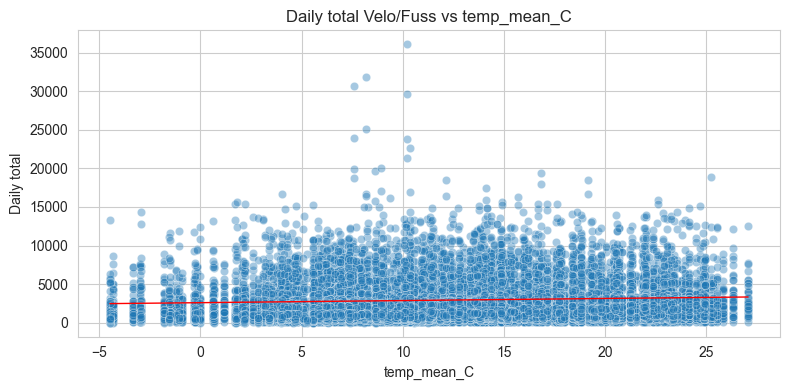

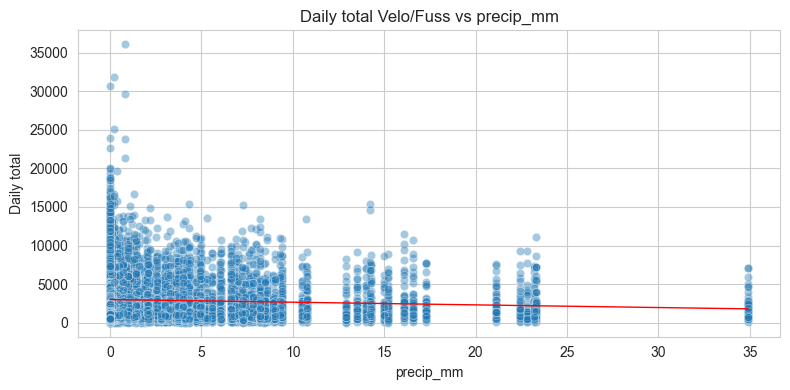

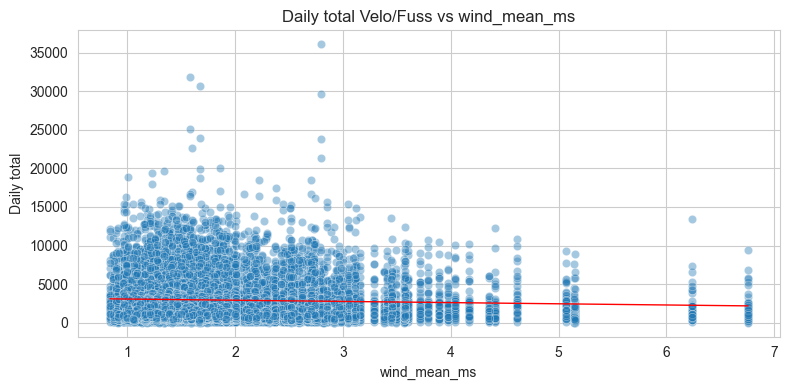

In [3]:
# ---------------- Scatter plots: daily_total vs weather ----------------
def plot_scatter_trends(merged_df, cols):
    """Scatterplots of daily_total vs selected meteo variables + linear trend."""
    print("\nGenerating scatterplots with linear trends...")
    for col in cols:
        df = merged_df[[col, "daily_total"]].dropna()
        x = df[col].values
        y = df["daily_total"].values

        coeffs = np.polyfit(x, y, 1)
        linear_func = np.poly1d(coeffs)
        x_sorted = np.sort(x)

        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=x, y=y, alpha=0.4)
        plt.plot(x_sorted, linear_func(x_sorted), color="red", linewidth=1)
        plt.title(f"Daily total Velo/Fuss vs {col}")
        plt.xlabel(col)
        plt.ylabel("Daily total")
        plt.tight_layout()
        plt.show()


# Run scatter plots for the main weather variables
plot_scatter_trends(df_stable, ["temp_mean_C", "precip_mm", "wind_mean_ms"])

#### **Interpretation – Scatter plots with trend lines**

No strong trends could be determined in the data. There are some weak trends but nothing significant. There are some weak trends but the effects of temperatur, wind, sunshine are not very great.




</br>

</br>



#### **Aggregated patterns by temperature, precipitation, weekday and weekend**

In this section we move from pointwise scatter plots to **aggregated group statistics**, in order to answer high-level questions such as:

- How do average daily counts vary across temperature ranges?
- How much lower are counts on rainy days compared to dry days?
- What are the differences between weekdays and weekends?

We use binned temperature, categorical precipitation levels, and calendar features (weekday, weekend) to compute mean daily totals and visualize them with bar plots.


Mean daily_total by temperature bin:
temp_bin
<0       2141.3
0–10     2809.5
10–15    3047.9
15–20    3001.4
20–25    3117.6
25–30    3037.6
Name: daily_total, dtype: float64


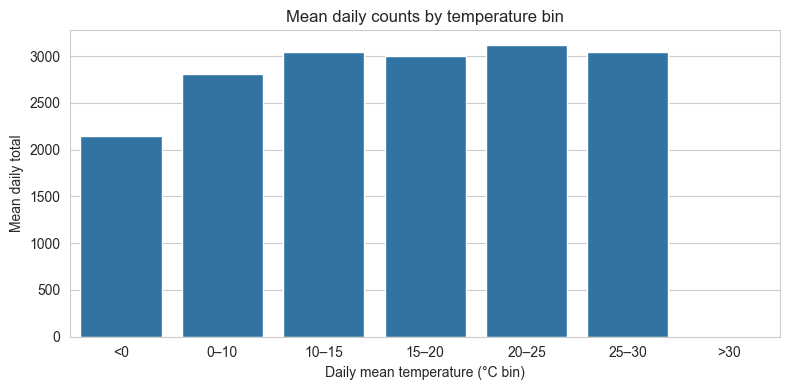


Mean daily_total by precipitation category:
precip_cat
Dry           3080.2
Light rain    2824.8
Rainy         2569.9
Name: daily_total, dtype: float64


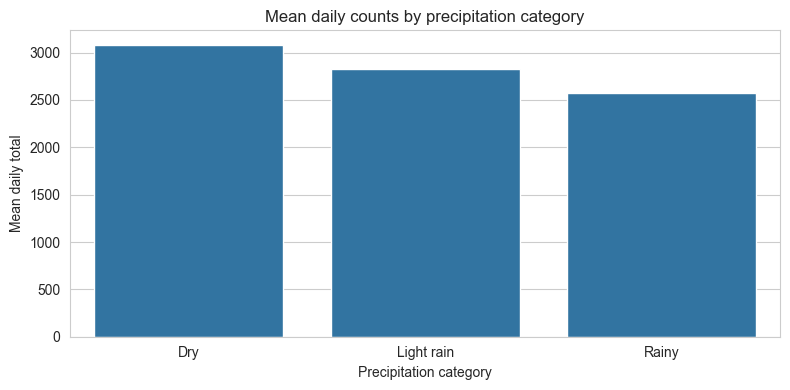


Mean daily_total by weekday:
weekday
Monday       2968.8
Tuesday      3183.9
Wednesday    3158.3
Thursday     3106.5
Friday       3177.6
Saturday     2856.9
Sunday       2014.8
Name: daily_total, dtype: float64


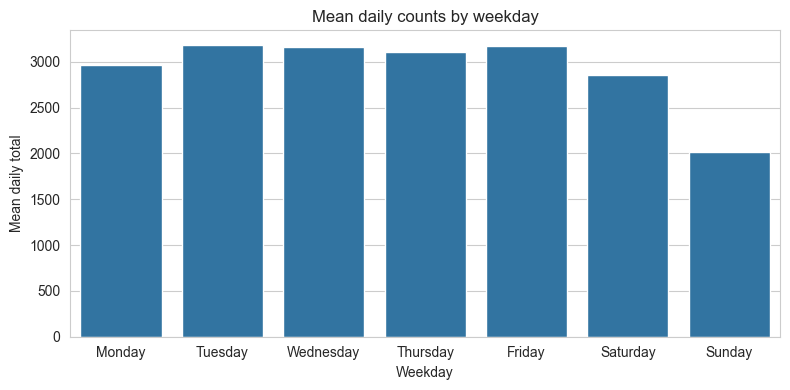


Mean daily_total: weekday vs weekend:
is_weekend
False    3118.7
True     2435.9
Name: daily_total, dtype: float64


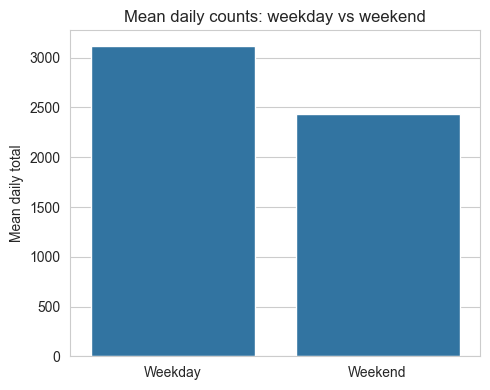

In [4]:
# ---------------- Aggregated patterns: temperature, precipitation, weekday ----------------
def analyze_relationships(merged_df):
    """
    Print and visualize group statistics to answer project questions.
    """
    df = merged_df.copy()

    # --- Temperature bins ---
    temp_bins = [-20, 0, 10, 15, 20, 25, 30, 45]
    temp_labels = ["<0", "0–10", "10–15", "15–20", "20–25", "25–30", ">30"]
    df["temp_bin"] = pd.cut(
        df["temp_mean_C"],
        bins=temp_bins,
        labels=temp_labels,
        include_lowest=True,
    )

    temp_means = df.groupby("temp_bin", observed=True)["daily_total"].mean().round(1)
    print("\nMean daily_total by temperature bin:")
    print(temp_means)

    temp_means_df = temp_means.reset_index(name="mean_daily_total")

    plt.figure(figsize=(8, 4))
    sns.barplot(data=temp_means_df, x="temp_bin", y="mean_daily_total")
    plt.ylabel("Mean daily total")
    plt.xlabel("Daily mean temperature (°C bin)")
    plt.title("Mean daily counts by temperature bin")
    plt.tight_layout()
    plt.show()

    # --- Precipitation categories ---
    precip_bins = [-0.01, 0.1, 5, 1000]
    precip_labels = ["Dry", "Light rain", "Rainy"]
    df["precip_cat"] = pd.cut(
        df["precip_mm"],
        bins=precip_bins,
        labels=precip_labels,
        include_lowest=True,
    )

    precip_means = df.groupby("precip_cat", observed=True)["daily_total"].mean().round(1)
    print("\nMean daily_total by precipitation category:")
    print(precip_means)

    precip_means_df = precip_means.reset_index(name="mean_daily_total")

    plt.figure(figsize=(8, 4))
    sns.barplot(data=precip_means_df, x="precip_cat", y="mean_daily_total")
    plt.ylabel("Mean daily total")
    plt.xlabel("Precipitation category")
    plt.title("Mean daily counts by precipitation category")
    plt.tight_layout()
    plt.show()

    # --- Weekday pattern ---
    weekday_means = df.groupby("weekday")["daily_total"].mean().round(1)

    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    print("\nMean daily_total by weekday:")
    print(weekday_means.reindex(order))

    weekday_means_df = weekday_means.reindex(order).reset_index(name="mean_daily_total")

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=weekday_means_df,
        x="weekday",
        y="mean_daily_total",
    )
    plt.ylabel("Mean daily total")
    plt.xlabel("Weekday")
    plt.title("Mean daily counts by weekday")
    plt.tight_layout()
    plt.show()

    # --- Weekday vs weekend ---
    weekend_means = df.groupby("is_weekend")["daily_total"].mean().round(1)
    print("\nMean daily_total: weekday vs weekend:")
    print(weekend_means)

    weekend_means_df = weekend_means.reset_index(name="mean_daily_total")
    weekend_means_df["label"] = weekend_means_df["is_weekend"].map(
        {False: "Weekday", True: "Weekend"}
    )

    plt.figure(figsize=(5, 4))
    sns.barplot(
        data=weekend_means_df,
        x="label",
        y="mean_daily_total",
    )
    plt.ylabel("Mean daily total")
    plt.xlabel("")
    plt.title("Mean daily counts: weekday vs weekend")
    plt.tight_layout()
    plt.show()


# Run aggregated pattern analysis
analyze_relationships(df_stable)

#### **Interpretation – Aggregated patterns**


There is more traffic on weekdays than on the weekend and also more traffic on Saturdays than on sundays. One conclusion is that most of the traffic is generated by people running errand or going to work, which explain why the weather has such a small effects. Weather affects if people want to go out, but most people go out because they have to.

</br>

</br>


#### **Correlation matrix – Linear relationships with weather**

Finally, we compute and visualise a **Pearson correlation matrix** for:

- `daily_total`
- `temp_mean_C`
- `precip_mm`
- `wind_mean_ms`

The goal is to quantify the strength and direction of *linear* relationships and to confirm the qualitative impressions from the scatter plots and aggregated views.



Correlation analysis (daily_total vs numeric features)


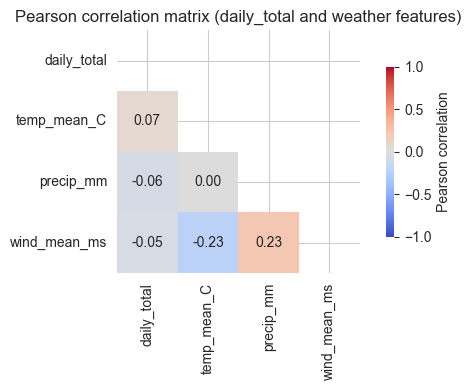


Top absolute correlations with daily_total:


,abs_corr
temp_mean_C,0.069950
precip_mm,0.056873
wind_mean_ms,0.047766


In [5]:
# ---------------- Correlation analysis ----------------
def analyze_correlations(merged_df):
    """
    Compute and visualize Pearson correlations between daily_total and numeric features.

    Includes:
    - Correlation matrix heatmap (Pearson)
    - Sorted absolute correlations with daily_total
    """
    print("\nCorrelation analysis (daily_total vs numeric features)")
    df = merged_df.copy()

    # Select numeric columns of interest
    numeric_cols = ["daily_total", "temp_mean_C", "precip_mm", "wind_mean_ms"]
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    if len(numeric_cols) < 2:
        print("Not enough numeric columns available for correlation analysis.")
        return

    corr_df = df[numeric_cols].corr(method="pearson")

    # Upper-triangular mask for a cleaner heatmap
    mask = np.triu(np.ones_like(corr_df, dtype=bool))

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        corr_df,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"label": "Pearson correlation", "shrink": 0.7},
    )
    plt.title("Pearson correlation matrix (daily_total and weather features)")
    plt.tight_layout()
    plt.show()

    # Absolute correlations with daily_total
    if "daily_total" in corr_df.columns:
        corr_with_target = corr_df["daily_total"].drop("daily_total").abs().sort_values(ascending=False)
        print("\nTop absolute correlations with daily_total:")
        display(corr_with_target.to_frame("abs_corr"))


# Run correlation analysis
analyze_correlations(df_stable)

**Interpretation – Correlation matrix**

The Pearson correlation matrix shows:

- Only weak linear correlations between `daily_total` and the individual weather variables (`temp_mean_C`, `precip_mm`, `wind_mean_ms`). 
  - The absolute values of the coefficients are clearly low, confirming that no single weather variable explains a large fraction of the variation in daily counts on its own.


- The signs of the correlations are consistent with expectations:
  - Slightly positive correlation with temperature (more counts on warmer days).
  - Slightly negative correlation with precipitation and wind speed (fewer counts on wet or windy days).

These results are aligned with the scatter plots and aggregated statistics, because:

- Weather effects are visible but moderate.
- Daily Velo/Fuss volumes are likely influenced by additional factors (network structure, calendar, special events, working life) beyond the simple weather features included here.